LOGISTIC REGRESSION

In [2]:
# Import the packages 
import IPython
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
from statistics import mode
from scipy import stats
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
train_v = pd.read_csv('./modified_diabetes_1.csv')

In [5]:
train_v.columns

Index(['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'patient_service', 'med_change', 'num_med', 'secondary_diag',
       'additional_diag', 'number_emergency_log', 'patient_service_log',
       'time_in_hospital_log', 'med_change_log', 'num_procedures_log',
       'number_outpatient_log', 'num_medications_log', 'number_inpatient_log',
       'race_1', 'race_2', 'race_3', 'race_4', 'ge

In [6]:
# Create a feature set
feature_set= ['race_1','race_2','race_3','race_4','gender_1','age','admission_type_id_3',
       'admission_type_id_4','admission_type_id_5','discharge_disposition_id_2', 
'discharge_disposition_id_7','discharge_disposition_id_10','discharge_disposition_id_18','discharge_disposition_id_19',
        'discharge_disposition_id_20','discharge_disposition_id_27','discharge_disposition_id_28','admission_source_id_4', 'admission_source_id_8',
        'admission_source_id_9','admission_source_id_11','num_lab_procedures','number_diagnoses', 'max_glu_serum_1.0', 'A1Cresult_1', 
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 
        'num_med', 'primary_diag_1','primary_diag_2','primary_diag_3','primary_diag_4','primary_diag_5','primary_diag_6','primary_diag_7','primary_diag_8',
        'number_emergency_log','patient_service_log', 'time_in_hospital_log', 'med_change_log',
       'num_procedures_log', 'number_outpatient_log', 'num_medications_log',
       'number_inpatient_log']

In [7]:

from collections import Counter

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
#from xgboost.sklearn import XGBClassifier 
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [8]:
train_input = train_v[feature_set]
train_output = train_v['readmitted']

Class 0: 79512
Class 1: 9607
Proportion: 8.28 : 1


<Axes: title={'center': 'Count (target)'}, xlabel='readmitted'>

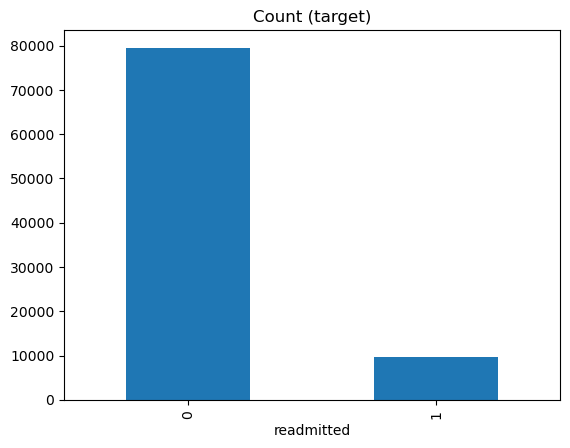

In [9]:
# Check the class for the outcome variable 
target_count=train_v['readmitted'].value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)')

In [10]:
x_train, x_test, y_train, y_test= model_selection.train_test_split(train_input, train_output, random_state = 0, test_size=0.1)

In [12]:
# Class Imbalance Processing: Using re-sampling method
from imblearn.over_sampling import SMOTE
from collections import Counter
print('Original dataset shape {}'.format(Counter(train_output)))
sm = SMOTE(random_state=20)
train_input_new, train_output_new = sm.fit_resample(train_input, train_output)
print('New dataset shape {}'.format(Counter(train_output_new)))

Original dataset shape Counter({0: 79512, 1: 9607})


c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


New dataset shape Counter({0: 79512, 1: 79512})


In [13]:
train_input_new = pd.DataFrame(train_input_new, columns = list(train_input.columns))

In [14]:
pd.concat([pd.DataFrame(train_input_new), pd.DataFrame(train_output_new)],axis=1).to_csv('./smote_data.csv',header=None)

In [15]:
# Again,split the training and testing dataset 
x_train_new, x_test_new, y_train_new, y_test_new= model_selection.train_test_split(train_input_new, train_output_new, random_state = 0, test_size=0.1)


In [17]:
# Run Logistic Regression Again 
LogR = LogisticRegression(fit_intercept=True, penalty='l2',random_state = 0)
print("Cross Validation Score: {:.2%}".format(np.mean(cross_val_score(LogR, x_train_new, y_train_new, cv=10))))
LogR.fit(x_train_new, y_train_new)
print("Test Set score: {:.2%}".format(LogR.score(x_test_new, y_test_new)))

c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.ht

Cross Validation Score: 73.61%
Test Set score: 73.93%


c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
y_test_predict = LogR.predict(x_test_new)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test_new, y_test_predict))
print("Precision:", precision_score(y_test_new, y_test_predict))
print("Recall:", recall_score(y_test_new, y_test_predict))
print("F1 Score:", f1_score(y_test_new, y_test_predict))
print("ROC-AUC:", roc_auc_score(y_test_new, LogR.predict_proba(x_test_new)[:, 1]))

Accuracy: 0.7392944727409922
Precision: 0.7547096271274523
Recall: 0.7200942109830172
F1 Score: 0.7369956863740168
ROC-AUC: 0.8181231262955797


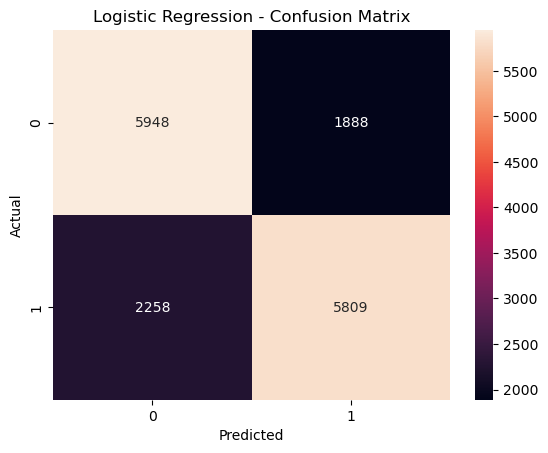

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_new, y_test_predict)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DECISION TREE

In [22]:
feature_set_dec = ['age', 'time_in_hospital', 'num_procedures', 'num_medications', 'number_outpatient_log', 
                 'number_emergency_log', 'number_inpatient_log', 'number_diagnoses', 'metformin', 
                 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 
                 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
                 'tolazamide', 'insulin', 'glyburide-metformin',
                 'race_1', 'race_2', 'race_3', 
                 'race_4', 'gender_1', 
                 'admission_source_id_4', 'admission_source_id_8', 'admission_source_id_9','admission_source_id_11', 
                 'discharge_disposition_id_2', 'discharge_disposition_id_7', 
                 'discharge_disposition_id_10', 'discharge_disposition_id_18', 
                 'max_glu_serum_1.0', 'A1Cresult_1', 
                 'primary_diag_1','primary_diag_2','primary_diag_3','primary_diag_4','primary_diag_5','primary_diag_6','primary_diag_7','primary_diag_8']

In [23]:
train_input = train_v[feature_set_dec]
train_output = train_v['readmitted']
train_v['readmitted'].value_counts()

readmitted
0    79512
1     9607
Name: count, dtype: int64

In [25]:
from imblearn.over_sampling import SMOTE
from collections import Counter
print('Original dataset shape {}'.format(Counter(train_output)))
smt = SMOTE(random_state=20)
train_input_new, train_output_new = smt.fit_resample(train_input, train_output)
print('New dataset shape {}'.format(Counter(train_output_new)))
train_input_new = pd.DataFrame(train_input_new, columns = list(train_input.columns))
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(train_input_new, train_output_new, test_size=0.20, random_state=0)

Original dataset shape Counter({0: 79512, 1: 9607})


c:\Users\ssanj\miniconda3\envs\conda_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


New dataset shape Counter({0: 79512, 1: 79512})


In [26]:
from sklearn.tree import DecisionTreeClassifier
dte = DecisionTreeClassifier(max_depth=28, criterion = "entropy", min_samples_split=10)
print("Cross Validation score: {:.2%}".format(np.mean(cross_val_score(dte, x_train_new, y_train_new, cv=10))))
dte.fit(x_train_new, y_train_new)
print("Dev Set score: {:.2%}".format(dte.score(x_test_new, y_test_new)))

Cross Validation score: 87.85%
Dev Set score: 87.84%


In [27]:
y_test_predict = dte.predict(x_test_new)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test_new, y_test_predict))
print("Precision:", precision_score(y_test_new, y_test_predict))
print("Recall:", recall_score(y_test_new, y_test_predict))
print("F1 Score:", f1_score(y_test_new, y_test_predict))
print("ROC-AUC:", roc_auc_score(y_test_new, y_test_predict))

Accuracy: 0.878446785096683
Precision: 0.892504804612428
Recall: 0.8642679900744417
F1 Score: 0.878159470532619
ROC-AUC: 0.8786433989262868


RANDOM FOREST

In [30]:
from sklearn.ensemble import RandomForestClassifier
forrest = RandomForestClassifier(n_estimators = 10, max_depth=25, criterion = "entropy", min_samples_split=10)
print("Cross Validation score: {:.2%}".format(np.mean(cross_val_score(forrest, x_train_new, y_train_new, cv=10))))
forrest.fit(x_train_new, y_train_new)
print("Dev Set score: {:.2%}".format(forrest.score(x_test_new, y_test_new)))

Cross Validation score: 89.60%
Dev Set score: 89.42%


In [31]:
y_test_predict = forrest.predict(x_test_new)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test_new, y_test_predict))
print("Precision:", precision_score(y_test_new, y_test_predict))
print("Recall:", recall_score(y_test_new, y_test_predict))
print("F1 Score:", f1_score(y_test_new, y_test_predict))
print("ROC-AUC:", roc_auc_score(y_test_new, y_test_predict))

Accuracy: 0.8941675837132527
Precision: 0.9339275993467611
Recall: 0.8514267990074442
F1 Score: 0.8907710280373832
ROC-AUC: 0.8947602595611017


In [33]:
forrest = RandomForestClassifier(n_estimators = 10, max_depth=25, criterion = "gini", min_samples_split=10)
print("Cross Validation score: {:.2%}".format(np.mean(cross_val_score(forrest, x_train_new, y_train_new, cv=10))))
forrest.fit(x_train_new, y_train_new)
print("Dev Set score: {:.2%}".format(forrest.score(x_test_new, y_test_new)))

Cross Validation score: 89.70%
Dev Set score: 89.78%


In [34]:
y_test_predict = forrest.predict(x_test_new)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test_new, y_test_predict))
print("Precision:", precision_score(y_test_new, y_test_predict))
print("Recall:", recall_score(y_test_new, y_test_predict))
print("F1 Score:", f1_score(y_test_new, y_test_predict))
print("ROC-AUC:", roc_auc_score(y_test_new, y_test_predict))

Accuracy: 0.8978462505895299
Precision: 0.9397335155449266
Recall: 0.8531637717121588
F1 Score: 0.894358640871403
ROC-AUC: 0.8984658514282823


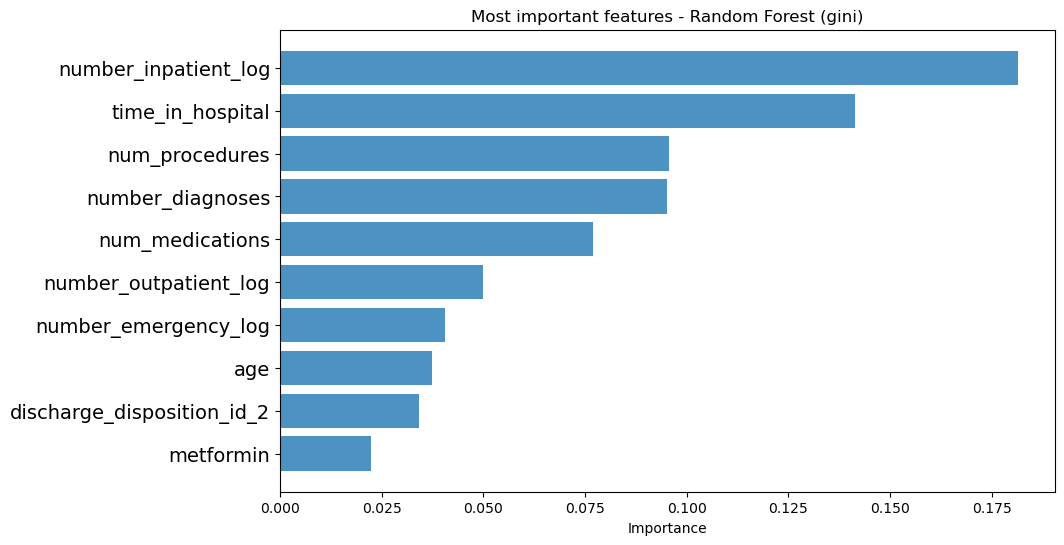

In [36]:
# Create list of top most features based on importance
feature_names = x_train_new.columns
feature_imports = forrest.feature_importances_
most_imp_features = pd.DataFrame([f for f in zip(feature_names,feature_imports)], columns=["Feature", "Importance"]).nlargest(10, "Importance")
most_imp_features.sort_values(by="Importance", inplace=True)
plt.figure(figsize=(10,6))
plt.barh(range(len(most_imp_features)), most_imp_features.Importance, align='center', alpha=0.8)
plt.yticks(range(len(most_imp_features)), most_imp_features.Feature, fontsize=14)
plt.xlabel('Importance')
plt.title('Most important features - Random Forest (gini)')
plt.show()

XGBOOST

In [37]:
import pandas as pd
import xgboost as xgb
import operator

In [38]:
def result (y_test_new, y_test_predict):
    print("Accuracy:", accuracy_score(y_test_new, y_test_predict))
    print("Precision:", precision_score(y_test_new, y_test_predict))
    print("Recall:", recall_score(y_test_new, y_test_predict))
    print("F1 Score:", f1_score(y_test_new, y_test_predict))
    print("ROC-AUC:", roc_auc_score(y_test_new, y_test_predict))

In [40]:
for max_depth in [3,4,5,6,7,8,9]:
    xgb_params = {
        'booster':'gbtree',
        'objective': 'binary:logistic', 
        "eta": 0.2, 
        "max_depth": max_depth,
        "colsample_bytree": 0.7, 
        'verbosity': 0  
    }
    num_rounds = 20000

    dtrain = xgb.DMatrix(x_train_new, label=y_train_new)
    dtest = xgb.DMatrix(x_test_new, label=y_test_new)
    evallist = [(dtrain, 'train'), (dtest, 'test')]
    
    gbm = xgb.train(
        xgb_params, 
        dtrain, 
        num_rounds, 
        evals=evallist, 
        verbose_eval=100, 
        early_stopping_rounds=100
    )
    
    y_predict = gbm.predict(dtest) 
    result(y_test_new, np.round(y_predict))

[0]	train-logloss:0.67973	test-logloss:0.67971
[100]	train-logloss:0.28819	test-logloss:0.29159
[200]	train-logloss:0.23130	test-logloss:0.23499
[300]	train-logloss:0.21359	test-logloss:0.21834
[400]	train-logloss:0.20558	test-logloss:0.21129
[500]	train-logloss:0.20019	test-logloss:0.20723
[600]	train-logloss:0.19660	test-logloss:0.20493
[700]	train-logloss:0.19385	test-logloss:0.20291
[800]	train-logloss:0.19178	test-logloss:0.20187
[900]	train-logloss:0.19010	test-logloss:0.20112
[1000]	train-logloss:0.18859	test-logloss:0.20037
[1100]	train-logloss:0.18730	test-logloss:0.20003
[1200]	train-logloss:0.18625	test-logloss:0.19979
[1300]	train-logloss:0.18530	test-logloss:0.19974
[1400]	train-logloss:0.18437	test-logloss:0.19951
[1500]	train-logloss:0.18357	test-logloss:0.19939
[1600]	train-logloss:0.18285	test-logloss:0.19947
Accuracy: 0.9323062411570507
Precision: 0.998429805153094
Recall: 0.8678039702233251
F1 Score: 0.9285453519630945
ROC-AUC: 0.9332006781304704
[0]	train-logloss:0.